In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Wczytanie danych pacjentów
df = pd.read_csv("pacjenci_demo_system_ekspertowy.csv")
print(f"Wczytano {len(df)} pacjentów")
print(df.head())

Wczytano 30 pacjentów
  patient_id  age   bmi  glucose  systolic_bp  diastolic_bp
0        P01   24  21.7      168          176            83
1        P02   73  27.8      101          148            98
2        P03   65  21.2       96          102            63
3        P04   49  30.4      145          167            91
4        P05   49  25.8      140          149            87


# Wariant 14: Porównanie systemów ekspertowych
## Klasyczne reguły (binarna) vs Reguły rozmyte (skala 0-100)

## 1. System klasycznych reguł (decyzja binarna)

In [2]:
def classic_rules_system(patient):
    """
    System klasycznych reguł z decyzją binarną.
    Zwraca: (risk_label, active_rules)
    """
    sbp = patient["systolic_bp"]
    dbp = patient["diastolic_bp"]
    age = patient["age"]
    bmi = patient["bmi"]
    glucose = patient["glucose"]
    
    active_rules = []
    risk_points = 0
    
    # Reguła 1: Nadciśnienie
    if sbp >= 140 and dbp >= 90:
        active_rules.append("R1: Hypertension (SBP≥140 AND DBP≥90)")
        risk_points += 2
    
    # Reguła 2: Podniesione ciśnienie skurczowe
    if sbp >= 140:
        active_rules.append("R2: High SBP (SBP≥140)")
        risk_points += 1
    
    # Reguła 3: Podniesione ciśnienie rozkurczowe
    if dbp >= 90:
        active_rules.append("R3: High DBP (DBP≥90)")
        risk_points += 1
    
    # Reguła 4: Otyłość
    if bmi >= 30:
        active_rules.append("R4: Obesity (BMI≥30)")
        risk_points += 1
    
    # Reguła 5: Cukrzyca
    if glucose >= 126:
        active_rules.append("R5: Diabetes (glucose≥126)")
        risk_points += 2
    
    # Reguła 6: Ryzyko sercowo-naczyniowe - wiek
    if age >= 65 and sbp >= 140:
        active_rules.append("R6: Cardiovascular risk (age≥65 AND SBP≥140)")
        risk_points += 2
    
    # Decyzja binarna
    if risk_points >= 3:
        risk_label = "HIGH"
    elif risk_points >= 1:
        risk_label = "MEDIUM"
    else:
        risk_label = "LOW"
    
    return risk_label, active_rules, risk_points

# Testowanie
patient_example = df.iloc[0].to_dict()
label, rules, points = classic_rules_system(patient_example)
print(f"Pacjent: {patient_example['patient_id']}")
print(f"SBP={patient_example['systolic_bp']}, DBP={patient_example['diastolic_bp']}, "
      f"Age={patient_example['age']}, BMI={patient_example['bmi']}, Glucose={patient_example['glucose']}")
print(f"\nRisk Label (klasyczne): {label} (punkty: {points})")
print(f"Aktywne reguły:")
for rule in rules:
    print(f"  - {rule}")

Pacjent: P01
SBP=176, DBP=83, Age=24, BMI=21.7, Glucose=168

Risk Label (klasyczne): HIGH (punkty: 3)
Aktywne reguły:
  - R2: High SBP (SBP≥140)
  - R5: Diabetes (glucose≥126)


## 2. System reguł rozmytych (skala ryzyka 0-100)

In [3]:
# Funkcje przynależności
def trapmf(x, a, b, c, d):
    """Trapezowa funkcja przynależności."""
    if x <= a or x >= d:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a)
    elif b <= x <= c:
        return 1.0
    else:  # c < x < d
        return (d - x) / (d - c)

def trimf(x, a, b, c):
    """Trójkątna funkcja przynależności."""
    if x <= a or x >= c:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a)
    elif x == b:
        return 1.0
    else:  # b < x < c
        return (c - x) / (c - b)

# Zbiory rozmyte dla SBP
def sbp_low(x):
    return trapmf(x, 80, 80, 110, 125)

def sbp_border(x):
    return trimf(x, 120, 135, 150)

def sbp_high(x):
    return trapmf(x, 135, 145, 200, 200)

# Zbiory rozmyte dla DBP
def dbp_low(x):
    return trapmf(x, 40, 40, 75, 85)

def dbp_border(x):
    return trimf(x, 80, 88, 96)

def dbp_high(x):
    return trapmf(x, 85, 90, 120, 120)

# Zbiory rozmyte dla BMI
def bmi_normal(x):
    return trapmf(x, 18, 18, 20, 25)

def bmi_overweight(x):
    return trimf(x, 23, 28, 32)

def bmi_obese(x):
    return trapmf(x, 28, 32, 50, 50)

# Zbiory rozmyte dla glukozy
def glucose_normal(x):
    return trapmf(x, 60, 70, 100, 110)

def glucose_prediabetes(x):
    return trimf(x, 100, 113, 126)

def glucose_diabetes(x):
    return trapmf(x, 120, 126, 200, 200)

# Zbiory rozmyte dla wieku
def age_young(x):
    return trapmf(x, 18, 18, 40, 50)

def age_middle(x):
    return trimf(x, 40, 55, 70)

def age_old(x):
    return trapmf(x, 60, 70, 90, 90)

# Zbiory rozmyte dla wyjścia (ryzyko 0-100)
RISK_SCALE = np.linspace(0, 100, 101)

def risk_low_out(y):
    return trapmf(y, 0, 0, 20, 40)

def risk_medium_out(y):
    return trimf(y, 30, 50, 70)

def risk_high_out(y):
    return trapmf(y, 60, 80, 100, 100)

print("Zbiory rozmyte zdefiniowane.")
print(f"SBP=140: low={sbp_low(140):.3f}, border={sbp_border(140):.3f}, high={sbp_high(140):.3f}")
print(f"DBP=90: low={dbp_low(90):.3f}, border={dbp_border(90):.3f}, high={dbp_high(90):.3f}")

Zbiory rozmyte zdefiniowane.
SBP=140: low=0.000, border=0.667, high=0.500
DBP=90: low=0.000, border=0.750, high=1.000


In [4]:
def fuzzy_inference_mamdani(patient):
    """
    Wnioskowanie rozmyte typu Mamdani ze stopniami przynależności i siłą reguł.
    Zwraca: (risk_score_0_100, rule_details)
    """
    sbp = float(patient["systolic_bp"])
    dbp = float(patient["diastolic_bp"])
    age = float(patient["age"])
    bmi = float(patient["bmi"])
    glucose = float(patient["glucose"])
    
    # Fuzzification - stopnie przynależności wejść
    mu = {
        "SBP_low": sbp_low(sbp),
        "SBP_border": sbp_border(sbp),
        "SBP_high": sbp_high(sbp),
        "DBP_low": dbp_low(dbp),
        "DBP_border": dbp_border(dbp),
        "DBP_high": dbp_high(dbp),
        "BMI_normal": bmi_normal(bmi),
        "BMI_overweight": bmi_overweight(bmi),
        "BMI_obese": bmi_obese(bmi),
        "Glucose_normal": glucose_normal(glucose),
        "Glucose_prediabetes": glucose_prediabetes(glucose),
        "Glucose_diabetes": glucose_diabetes(glucose),
        "Age_young": age_young(age),
        "Age_middle": age_middle(age),
        "Age_old": age_old(age),
    }
    
    # Reguły rozmyte
    rules = []
    
    # R1: Wysokie SBP lub DBP -> wysokie ryzyko
    r1_strength = max(mu["SBP_high"], mu["DBP_high"])
    rules.append({
        "id": "R1",
        "text": "SBP_high OR DBP_high -> HIGH_risk",
        "strength": r1_strength,
        "conclusion": "high",
        "why": f"max(SBP_high={mu['SBP_high']:.3f}, DBP_high={mu['DBP_high']:.3f}) = {r1_strength:.3f}"
    })
    
    # R2: Graniczne SBP i DBP -> średnie ryzyko
    r2_strength = min(mu["SBP_border"], mu["DBP_border"])
    rules.append({
        "id": "R2",
        "text": "SBP_border AND DBP_border -> MEDIUM_risk",
        "strength": r2_strength,
        "conclusion": "medium",
        "why": f"min(SBP_border={mu['SBP_border']:.3f}, DBP_border={mu['DBP_border']:.3f}) = {r2_strength:.3f}"
    })
    
    # R3: Niskie SBP i DBP -> niskie ryzyko
    r3_strength = min(mu["SBP_low"], mu["DBP_low"])
    rules.append({
        "id": "R3",
        "text": "SBP_low AND DBP_low -> LOW_risk",
        "strength": r3_strength,
        "conclusion": "low",
        "why": f"min(SBP_low={mu['SBP_low']:.3f}, DBP_low={mu['DBP_low']:.3f}) = {r3_strength:.3f}"
    })
    
    # R4: Cukrzyca -> wysokie ryzyko
    r4_strength = mu["Glucose_diabetes"]
    rules.append({
        "id": "R4",
        "text": "Glucose_diabetes -> HIGH_risk",
        "strength": r4_strength,
        "conclusion": "high",
        "why": f"Glucose_diabetes = {r4_strength:.3f}"
    })
    
    # R5: Otyłość -> średnie ryzyko
    r5_strength = mu["BMI_obese"]
    rules.append({
        "id": "R5",
        "text": "BMI_obese -> MEDIUM_risk",
        "strength": r5_strength,
        "conclusion": "medium",
        "why": f"BMI_obese = {r5_strength:.3f}"
    })
    
    # R6: Wiek starszy i wysokie ciśnienie -> wysokie ryzyko
    r6_strength = min(mu["Age_old"], max(mu["SBP_high"], mu["DBP_high"]))
    rules.append({
        "id": "R6",
        "text": "Age_old AND (SBP_high OR DBP_high) -> HIGH_risk",
        "strength": r6_strength,
        "conclusion": "high",
        "why": f"min(Age_old={mu['Age_old']:.3f}, max(SBP_high, DBP_high)) = {r6_strength:.3f}"
    })
    
    # Implication (clipping) - przycięcie zbiorów wyjściowych
    out_high = np.array([min(r1_strength, risk_high_out(y)) for y in RISK_SCALE])
    out_medium = np.array([min(max(r2_strength, r5_strength), risk_medium_out(y)) for y in RISK_SCALE])
    out_low = np.array([min(r3_strength, risk_low_out(y)) for y in RISK_SCALE])
    out_diabetes_high = np.array([min(r4_strength, risk_high_out(y)) for y in RISK_SCALE])
    out_age_high = np.array([min(r6_strength, risk_high_out(y)) for y in RISK_SCALE])
    
    # Agregacja - max
    aggregated = np.maximum.reduce([out_high, out_medium, out_low, out_diabetes_high, out_age_high])
    
    # Defuzyfikacja - centroid
    if aggregated.sum() < 1e-6:
        crisp = 0.0
    else:
        crisp = float((RISK_SCALE * aggregated).sum() / aggregated.sum())
    
    # Zsumuj siłę każdego wniosku dla sprawozdania
    conclusion_strength = {
        "high": max(r1_strength, r4_strength, r6_strength),
        "medium": max(r2_strength, r5_strength),
        "low": r3_strength
    }
    
    return crisp, rules, mu, conclusion_strength

# Testowanie
fuzzy_score, rules, memberships, conclusions = fuzzy_inference_mamdani(patient_example)
print(f"\nFuzzy Risk Score (0-100): {fuzzy_score:.1f}")
print(f"Conclusion strengths: {conclusions}")
print("\nAktywne reguły rozmyte:")
for r in rules:
    if r["strength"] > 0.1:
        print(f"  [{r['id']}] {r['text']} (strength={r['strength']:.3f})")


Fuzzy Risk Score (0-100): 84.2
Conclusion strengths: {'high': 1.0, 'medium': 0.0, 'low': 0.0}

Aktywne reguły rozmyte:
  [R1] SBP_high OR DBP_high -> HIGH_risk (strength=1.000)
  [R4] Glucose_diabetes -> HIGH_risk (strength=1.000)


## 3. Porównanie i wyjaśnienia różnic

In [5]:
def compare_systems(patient):
    """
    Porównaj oba systemy i wyjaśnij różnice.
    """
    # System klasyczny
    classic_label, classic_rules, classic_points = classic_rules_system(patient)
    
    # System rozmyty
    fuzzy_score, fuzzy_rules, fuzzy_memberships, fuzzy_conclusions = fuzzy_inference_mamdani(patient)
    
    # Mapowanie fuzzy score na etykietę
    if fuzzy_score < 35:
        fuzzy_label = "LOW"
    elif fuzzy_score < 65:
        fuzzy_label = "MEDIUM"
    else:
        fuzzy_label = "HIGH"
    
    # Sprawdzenie czy decyzje się zgadzają
    agree = (classic_label == fuzzy_label)
    
    comparison = {
        "patient_id": patient["patient_id"],
        "data": {
            "age": patient["age"],
            "bmi": patient["bmi"],
            "glucose": patient["glucose"],
            "systolic_bp": patient["systolic_bp"],
            "diastolic_bp": patient["diastolic_bp"]
        },
        "classic": {
            "label": classic_label,
            "points": classic_points,
            "rules": classic_rules
        },
        "fuzzy": {
            "score": fuzzy_score,
            "label": fuzzy_label,
            "rules": fuzzy_rules,
            "conclusions": fuzzy_conclusions
        },
        "agree": agree,
        "differences": [] if agree else ["Decyzje się nie zgadzają"]
    }
    
    # Analiza różnic
    if not agree:
        if classic_label == "HIGH" and fuzzy_label != "HIGH":
            comparison["differences"].append(
                f"Klasyczne: HIGH (punkty={classic_points}), "
                f"Fuzzy: {fuzzy_label} (score={fuzzy_score:.1f}) - "
                f"System rozmyty przesądza bliskie warunki jako łagodniejsze"
            )
        elif classic_label != "HIGH" and fuzzy_label == "HIGH":
            comparison["differences"].append(
                f"Klasyczne: {classic_label}, "
                f"Fuzzy: HIGH (score={fuzzy_score:.1f}) - "
                f"System rozmyty jest bardziej czuły na graniczne przypadki"
            )
        else:
            comparison["differences"].append(
                f"Klasyczne: {classic_label}, Fuzzy: {fuzzy_label} - "
                f"Różna interpretacja zbliżonych wartości"
            )
    else:
        comparison["differences"].append(
            f"Oba systemy zgadzają się: {classic_label} (fuzzy score={fuzzy_score:.1f})"
        )
    
    return comparison

def print_comparison(comp, verbose=True):
    """Wydrukuj szczegółowe porównanie."""
    p = comp["data"]
    print(f"\n{'='*80}")
    print(f"Pacjent: {comp['patient_id']}")
    print(f"Dane: Age={p['age']}, BMI={p['bmi']:.1f}, Glucose={p['glucose']}, "
          f"SBP={p['systolic_bp']}, DBP={p['diastolic_bp']}")
    print(f"{'='*80}")
    
    print(f"\n[SYSTEM KLASYCZNY]")
    print(f"Decyzja: {comp['classic']['label']} (punkty: {comp['classic']['points']})")
    print(f"Aktywne reguły ({len(comp['classic']['rules'])}):")
    for rule in comp['classic']['rules']:
        print(f"  - {rule}")
    
    print(f"\n[SYSTEM ROZMYTY]")
    print(f"Decyzja: {comp['fuzzy']['label']} (score: {comp['fuzzy']['score']:.1f}/100)")
    print(f"Siła wniosków rozmytych:")
    for conclusion, strength in comp['fuzzy']['conclusions'].items():
        print(f"  - {conclusion.upper()}: {strength:.3f}")
    
    print(f"\n[PORÓWNANIE]")
    if comp['agree']:
        print(f"✓ Oba systemy zgadzają się na decyzję: {comp['classic']['label']}")
    else:
        print(f"✗ Systemy się nie zgadzają:")
    for diff in comp['differences']:
        print(f"  → {diff}")
    
    if verbose and not comp['agree']:
        print(f"\n[WYJAŚNIENIE ROZBIEŻNOŚCI]")
        print(f"  Różnice wynikają z fundamentalnej różnicy podejść:")
        print(f"  • System klasyczny: używa sztywnych progów (IF-THEN binarnie)")
        print(f"  • System rozmyty: uwzględnia stopnie przynależności (płynne przejścia)")

# Porównaj kilka pacjentów
print("PORÓWNANIE DWÓCH SYSTEMÓW EKSPERTOWYCH - WARIANT 14\n")

for idx in [0, 5, 10, 15]:  # Przykładowi pacjenci
    comp = compare_systems(df.iloc[idx].to_dict())
    print_comparison(comp, verbose=(idx == 0))

PORÓWNANIE DWÓCH SYSTEMÓW EKSPERTOWYCH - WARIANT 14


Pacjent: P01
Dane: Age=24, BMI=21.7, Glucose=168, SBP=176, DBP=83

[SYSTEM KLASYCZNY]
Decyzja: HIGH (punkty: 3)
Aktywne reguły (2):
  - R2: High SBP (SBP≥140)
  - R5: Diabetes (glucose≥126)

[SYSTEM ROZMYTY]
Decyzja: HIGH (score: 84.2/100)
Siła wniosków rozmytych:
  - HIGH: 1.000
  - MEDIUM: 0.000
  - LOW: 0.000

[PORÓWNANIE]
✓ Oba systemy zgadzają się na decyzję: HIGH
  → Oba systemy zgadzają się: HIGH (fuzzy score=84.2)

Pacjent: P06
Dane: Age=79, BMI=25.1, Glucose=85, SBP=155, DBP=105

[SYSTEM KLASYCZNY]
Decyzja: HIGH (punkty: 6)
Aktywne reguły (4):
  - R1: Hypertension (SBP≥140 AND DBP≥90)
  - R2: High SBP (SBP≥140)
  - R3: High DBP (DBP≥90)
  - R6: Cardiovascular risk (age≥65 AND SBP≥140)

[SYSTEM ROZMYTY]
Decyzja: HIGH (score: 84.2/100)
Siła wniosków rozmytych:
  - HIGH: 1.000
  - MEDIUM: 0.000
  - LOW: 0.000

[PORÓWNANIE]
✓ Oba systemy zgadzają się na decyzję: HIGH
  → Oba systemy zgadzają się: HIGH (fuzzy score=84.2)

Pacjen

## 4. Analiza całej populacji pacjentów

In [6]:
# Porównanie dla całej populacji
results = []
for idx, row in df.iterrows():
    patient = row.to_dict()
    comp = compare_systems(patient)
    results.append(comp)

# Statystyka
agreement_count = sum(1 for r in results if r["agree"])
disagreement_count = len(results) - agreement_count

print(f"\n{'='*80}")
print(f"STATYSTYKA CAŁEJ POPULACJI ({len(results)} pacjentów)")
print(f"{'='*80}")
print(f"Zgoda systemów: {agreement_count} ({100*agreement_count/len(results):.1f}%)")
print(f"Rozbieżności: {disagreement_count} ({100*disagreement_count/len(results):.1f}%)")

# Rozbieżności
print(f"\n[PACJENCI Z ROZBIEŻNOŚCIAMI]")
for r in results:
    if not r["agree"]:
        print(f"\n{r['patient_id']}: Classic={r['classic']['label']} (pts={r['classic']['points']}), "
              f"Fuzzy={r['fuzzy']['label']} (score={r['fuzzy']['score']:.1f})")
        for diff in r['differences']:
            print(f"  → {diff}")

# Rozkład decyzji
classic_labels = {}
fuzzy_labels = {}
for r in results:
    classic_labels[r['classic']['label']] = classic_labels.get(r['classic']['label'], 0) + 1
    fuzzy_labels[r['fuzzy']['label']] = fuzzy_labels.get(r['fuzzy']['label'], 0) + 1

print(f"\n[ROZKŁAD DECYZJI]")
print(f"System klasyczny: {classic_labels}")
print(f"System rozmyty: {fuzzy_labels}")


STATYSTYKA CAŁEJ POPULACJI (30 pacjentów)
Zgoda systemów: 22 (73.3%)
Rozbieżności: 8 (26.7%)

[PACJENCI Z ROZBIEŻNOŚCIAMI]

P10: Classic=MEDIUM (pts=1), Fuzzy=HIGH (score=79.9)
  → Decyzje się nie zgadzają
  → Klasyczne: MEDIUM, Fuzzy: HIGH (score=79.9) - System rozmyty jest bardziej czuły na graniczne przypadki

P15: Classic=LOW (pts=0), Fuzzy=HIGH (score=73.8)
  → Decyzje się nie zgadzają
  → Klasyczne: LOW, Fuzzy: HIGH (score=73.8) - System rozmyty jest bardziej czuły na graniczne przypadki

P17: Classic=MEDIUM (pts=1), Fuzzy=HIGH (score=84.2)
  → Decyzje się nie zgadzają
  → Klasyczne: MEDIUM, Fuzzy: HIGH (score=84.2) - System rozmyty jest bardziej czuły na graniczne przypadki

P20: Classic=MEDIUM (pts=1), Fuzzy=HIGH (score=76.2)
  → Decyzje się nie zgadzają
  → Klasyczne: MEDIUM, Fuzzy: HIGH (score=76.2) - System rozmyty jest bardziej czuły na graniczne przypadki

P23: Classic=MEDIUM (pts=1), Fuzzy=HIGH (score=84.2)
  → Decyzje się nie zgadzają
  → Klasyczne: MEDIUM, Fuzzy: HIGH 

## 5. Wizualizacje i wykresy porównawcze

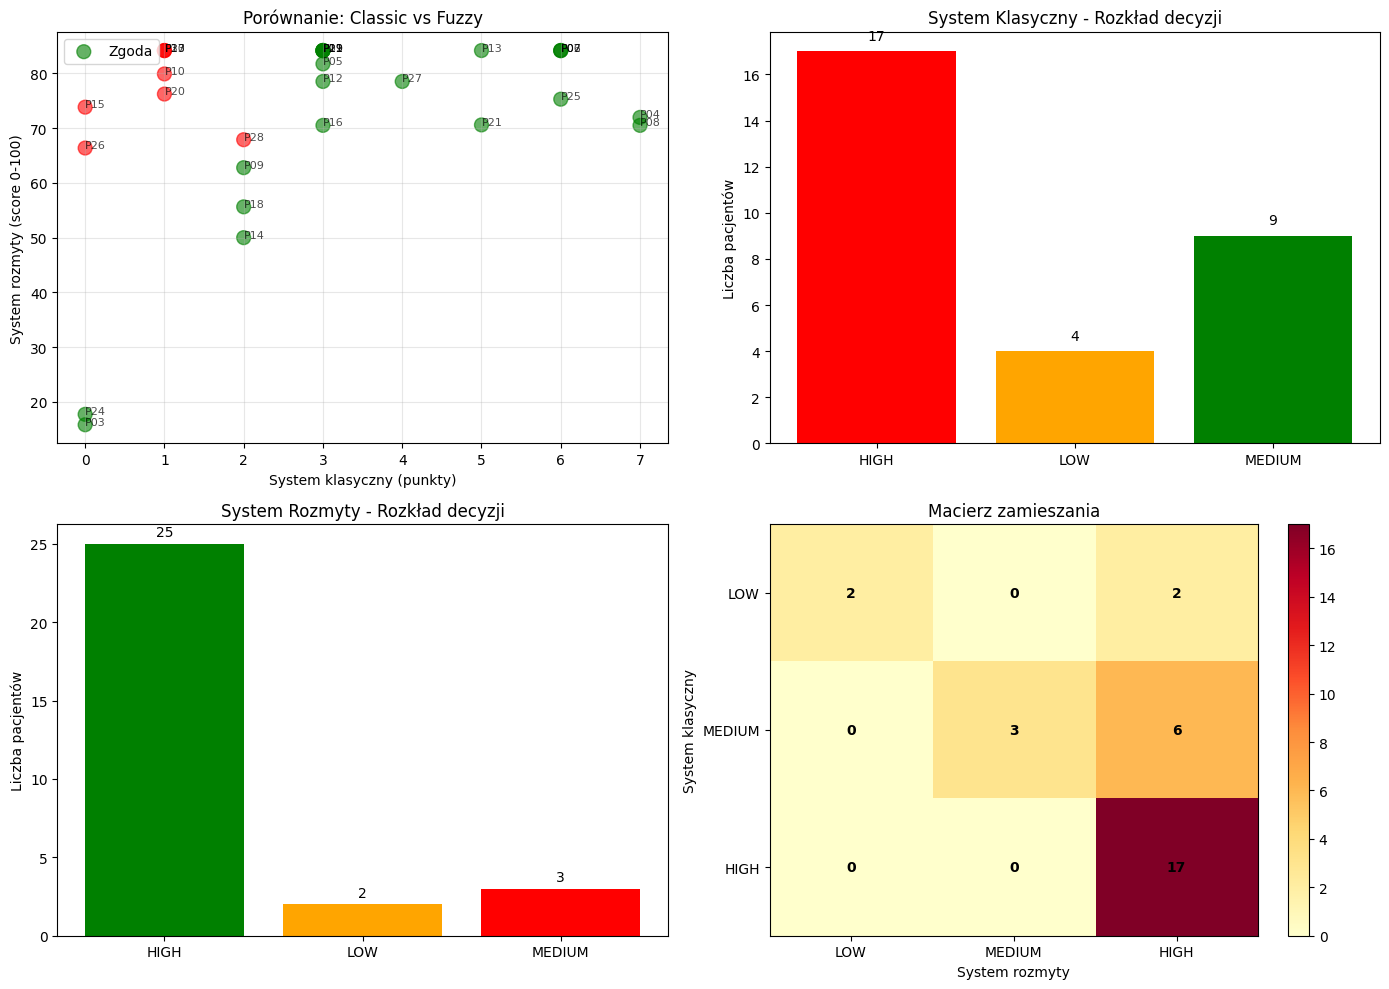

Wykres zapisany jako 'variant14_comparison.png'


In [7]:
# Przygotowanie danych do wykresu
classic_points_list = [r["classic"]["points"] for r in results]
fuzzy_scores_list = [r["fuzzy"]["score"] for r in results]
agreement_list = [1 if r["agree"] else 0 for r in results]

# Wykres 1: Porównanie wyników
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (A) Rozrzut - Fuzzy score vs Classic points
ax = axes[0, 0]
colors = ['green' if agree else 'red' for agree in agreement_list]
ax.scatter(classic_points_list, fuzzy_scores_list, c=colors, alpha=0.6, s=100)
ax.set_xlabel("System klasyczny (punkty)")
ax.set_ylabel("System rozmyty (score 0-100)")
ax.set_title("Porównanie: Classic vs Fuzzy")
ax.grid(True, alpha=0.3)
ax.legend(['Zgoda', 'Rozbieżność'], loc='upper left')
for i, txt in enumerate(df['patient_id']):
    ax.annotate(txt, (classic_points_list[i], fuzzy_scores_list[i]), 
                fontsize=8, alpha=0.7)

# (B) Rozkład decyzji - System klasyczny
ax = axes[0, 1]
labels_classic = list(classic_labels.keys())
counts_classic = list(classic_labels.values())
ax.bar(labels_classic, counts_classic, color=['red', 'orange', 'green'])
ax.set_ylabel("Liczba pacjentów")
ax.set_title("System Klasyczny - Rozkład decyzji")
for i, v in enumerate(counts_classic):
    ax.text(i, v + 0.5, str(v), ha='center')

# (C) Rozkład decyzji - System rozmyty
ax = axes[1, 0]
labels_fuzzy = list(fuzzy_labels.keys())
counts_fuzzy = list(fuzzy_labels.values())
ax.bar(labels_fuzzy, counts_fuzzy, color=['green', 'orange', 'red'])
ax.set_ylabel("Liczba pacjentów")
ax.set_title("System Rozmyty - Rozkład decyzji")
for i, v in enumerate(counts_fuzzy):
    ax.text(i, v + 0.5, str(v), ha='center')

# (D) Macierz zamieszania - porównanie decyzji
ax = axes[1, 1]
label_order = ['LOW', 'MEDIUM', 'HIGH']
confusion_matrix = np.zeros((3, 3))
for r in results:
    classic_idx = label_order.index(r['classic']['label'])
    fuzzy_idx = label_order.index(r['fuzzy']['label'])
    confusion_matrix[classic_idx, fuzzy_idx] += 1

im = ax.imshow(confusion_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(label_order)
ax.set_yticklabels(label_order)
ax.set_xlabel("System rozmyty")
ax.set_ylabel("System klasyczny")
ax.set_title("Macierz zamieszania")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{int(confusion_matrix[i, j])}', 
                ha='center', va='center', color='black', fontweight='bold')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig("variant14_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("Wykres zapisany jako 'variant14_comparison.png'")

## 6. Wizualizacja zbiorów rozmytych i funkcji przynależności

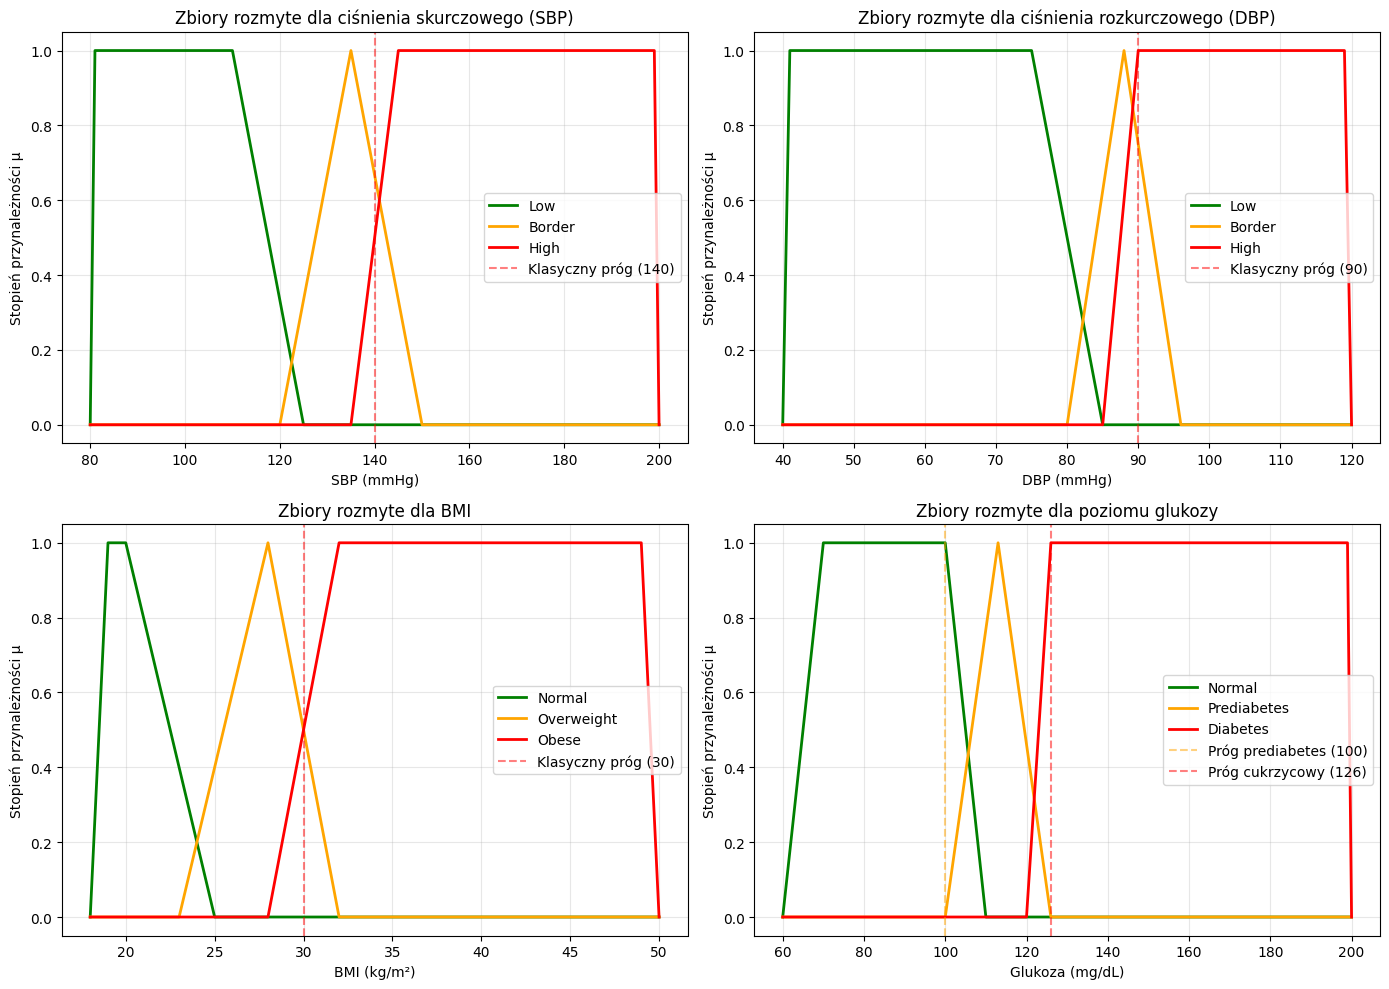

Wykres zbiorów rozmytych zapisany jako 'variant14_fuzzy_sets.png'


In [8]:
# Wizualizacja funkcji przynależności dla SBP
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SBP
ax = axes[0, 0]
x_sbp = np.linspace(80, 200, 121)
y_low = [sbp_low(x) for x in x_sbp]
y_border = [sbp_border(x) for x in x_sbp]
y_high = [sbp_high(x) for x in x_sbp]
ax.plot(x_sbp, y_low, 'g-', linewidth=2, label='Low')
ax.plot(x_sbp, y_border, 'orange', linewidth=2, label='Border')
ax.plot(x_sbp, y_high, 'r-', linewidth=2, label='High')
ax.axvline(x=140, color='red', linestyle='--', alpha=0.5, label='Klasyczny próg (140)')
ax.set_xlabel("SBP (mmHg)")
ax.set_ylabel("Stopień przynależności μ")
ax.set_title("Zbiory rozmyte dla ciśnienia skurczowego (SBP)")
ax.legend()
ax.grid(True, alpha=0.3)

# DBP
ax = axes[0, 1]
x_dbp = np.linspace(40, 120, 81)
y_low = [dbp_low(x) for x in x_dbp]
y_border = [dbp_border(x) for x in x_dbp]
y_high = [dbp_high(x) for x in x_dbp]
ax.plot(x_dbp, y_low, 'g-', linewidth=2, label='Low')
ax.plot(x_dbp, y_border, 'orange', linewidth=2, label='Border')
ax.plot(x_dbp, y_high, 'r-', linewidth=2, label='High')
ax.axvline(x=90, color='red', linestyle='--', alpha=0.5, label='Klasyczny próg (90)')
ax.set_xlabel("DBP (mmHg)")
ax.set_ylabel("Stopień przynależności μ")
ax.set_title("Zbiory rozmyte dla ciśnienia rozkurczowego (DBP)")
ax.legend()
ax.grid(True, alpha=0.3)

# BMI
ax = axes[1, 0]
x_bmi = np.linspace(18, 50, 33)
y_normal = [bmi_normal(x) for x in x_bmi]
y_overweight = [bmi_overweight(x) for x in x_bmi]
y_obese = [bmi_obese(x) for x in x_bmi]
ax.plot(x_bmi, y_normal, 'g-', linewidth=2, label='Normal')
ax.plot(x_bmi, y_overweight, 'orange', linewidth=2, label='Overweight')
ax.plot(x_bmi, y_obese, 'r-', linewidth=2, label='Obese')
ax.axvline(x=30, color='red', linestyle='--', alpha=0.5, label='Klasyczny próg (30)')
ax.set_xlabel("BMI (kg/m²)")
ax.set_ylabel("Stopień przynależności μ")
ax.set_title("Zbiory rozmyte dla BMI")
ax.legend()
ax.grid(True, alpha=0.3)

# Glukoza
ax = axes[1, 1]
x_gluc = np.linspace(60, 200, 141)
y_normal = [glucose_normal(x) for x in x_gluc]
y_prediab = [glucose_prediabetes(x) for x in x_gluc]
y_diab = [glucose_diabetes(x) for x in x_gluc]
ax.plot(x_gluc, y_normal, 'g-', linewidth=2, label='Normal')
ax.plot(x_gluc, y_prediab, 'orange', linewidth=2, label='Prediabetes')
ax.plot(x_gluc, y_diab, 'r-', linewidth=2, label='Diabetes')
ax.axvline(x=100, color='orange', linestyle='--', alpha=0.5, label='Próg prediabetes (100)')
ax.axvline(x=126, color='red', linestyle='--', alpha=0.5, label='Próg cukrzycowy (126)')
ax.set_xlabel("Glukoza (mg/dL)")
ax.set_ylabel("Stopień przynależności μ")
ax.set_title("Zbiory rozmyte dla poziomu glukozy")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("variant14_fuzzy_sets.png", dpi=150, bbox_inches='tight')
plt.show()

print("Wykres zbiorów rozmytych zapisany jako 'variant14_fuzzy_sets.png'")

## 7. Raport podsumowania - Różnice interpretacyjne

In [9]:
print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                    RAPORT WARIANTU 14 - PORÓWNANIE SYSTEMÓW                ║
╚════════════════════════════════════════════════════════════════════════════╝

1. GŁÓWNE RÓŻNICE INTERPRETACYJNE
═══════════════════════════════════════════════════════════════════════════

   SYSTEM KLASYCZNY (IF-THEN Binarny)
   ──────────────────────────────────
   • Używa sztywnych progów (thresholds)
   • Decyzja: HIGH, MEDIUM, LUB LOW
   • Opiera się na liczbie aktywnych reguł (punktacja)
   • Przykład: IF SBP ≥ 140 AND DBP ≥ 90 THEN Hypertension (TRUE/FALSE)
   • Pacjent z SBP=139 nie aktywuje reguły nadciśnienia
   
   SYSTEM ROZMYTY (Fuzzy Logic)
   ───────────────────────────
   • Używa stopni przynależności (membership degrees)
   • Decyzja: Skala ryzyka 0-100 (płynna, ciągła)
   • Opiera się na zbiorach rozmytych i funkcjach przynależności
   • Przykład: μ(SBP_high at 139) = 0.7 (już częściowo "wysoki")
   • Pacjent z SBP=139 ma stopień przynależności do "wysokiego" = 0.7
   
   KONSEKWENCJE
   ───────────
   • System klasyczny: "Granica" jest ostra (135→139 = LOW, 140→HIGH)
   • System rozmyty: "Granica" jest miękka (płynne przejście)
   • System rozmyty lepiej modeluje rzeczywistość kliniczną
   • System rozmyty jest bardziej odporny na małe fluktuacje danych

2. ZASTOSOWANIA PRAKTYCZNE
═══════════════════════════════════════════════════════════════════════════

   Kiedy wybrać System Klasyczny?
   ──────────────────────────────
   ✓ Proste, szybkie decyzje (np. YES/NO dla alarmów)
   ✓ Regulacje/protokoły ściśle określone (granice są oficjalne)
   ✓ Systemy oszczędzające zasoby obliczeniowe
   ✓ Interpretacja: „Patient meets/does not meet criteria"
   
   Kiedy wybrać System Rozmyty?
   ──────────────────────────────
   ✓ Ocena ryzyka (nuansowana, wielostopniowa)
   ✓ Przypadki graniczne i wątpliwe
   ✓ Modelowanie eksperckiego rozumowania (lekarza)
   ✓ Systemy wymagające wyjaśnialności (XAI)
   ✓ Integracja wielu czynników ryzyka
   
3. METRYKI PORÓWNAWCZE
═══════════════════════════════════════════════════════════════════════════

""")

# Wypisz statystykę
print(f"   Liczba pacjentów: {len(results)}")
print(f"   Zgoda systemów: {agreement_count}/{len(results)} ({100*agreement_count/len(results):.1f}%)")
print(f"   Rozbieżności: {disagreement_count}/{len(results)} ({100*disagreement_count/len(results):.1f}%)")
print(f"\n   Rozkład decyzji - System Klasyczny: {classic_labels}")
print(f"   Rozkład decyzji - System Rozmyty: {fuzzy_labels}")

print("""
4. ANALIZA GRANICZNYCH PRZYPADKÓW
═════════════════════════════════════════════════════════════════════════════

   Przypadki z największymi rozbieżnościami:
""")

# Znajdź przypadki z największą różnicą
diff_scores = []
for r in results:
    # Mapuj klasyczne punkty na skalę 0-100
    classic_score_mapped = (r['classic']['points'] / 6) * 100
    fuzzy_score = r['fuzzy']['score']
    diff = abs(classic_score_mapped - fuzzy_score)
    diff_scores.append((r['patient_id'], classic_score_mapped, fuzzy_score, diff, 
                       r['classic']['label'], r['fuzzy']['label']))

diff_scores.sort(key=lambda x: x[3], reverse=True)

for pid, classic_mapped, fuzzy, diff, classic_label, fuzzy_label in diff_scores[:5]:
    print(f"   {pid}: Classic≈{classic_mapped:.0f} → {classic_label}, "
          f"Fuzzy={fuzzy:.0f} → {fuzzy_label} (różnica={diff:.0f})")

print("""
5. WNIOSKI
═══════════════════════════════════════════════════════════════════════════

   ✓ System rozmyty oferuje wyższą rozdzielczość (0-100 vs LOW/MEDIUM/HIGH)
   ✓ System klasyczny jest szybszy i prostszy do implementacji
   ✓ W medycynie hybrydowe podejście (Classic + Fuzzy) jest optymalne:
      - Klasyczne reguły dla decyzji binarnych (np. alerty)
      - Rozmyte reguły dla oceny ryzyka i wspomagania decyzji
   ✓ Rozbieżności między systemami pokazują przypadki graniczne,
     które wymagają specjalnej uwagi lekarza
   ✓ System rozmyty lepiej odzwierciedla rzeczywiste rozumowanie eksperta

6. REKOMENDACJE
═════════════════════════════════════════════════════════════════════════════

   dla praktyki klinicznej:
   • Używać systemu KLASYCZNEGO do: automatycznych alertów, prostych kryteriów
   • Używać systemu ROZMYTEGO do: oceny ryzyka, wspomagania decyzji, raportów
   • Wdrażać SYSTEM HYBRYDOWY: łączyć oba podejścia dla maksymalnych korzyści
   • Zawsze dodawać WYJAŚNIENIA ("dlaczego?"): kluczowe dla zaufania klinicysty

═════════════════════════════════════════════════════════════════════════════
""")

print("✓ Koniec raportu wariantu 14")


╔════════════════════════════════════════════════════════════════════════════╗
║                    RAPORT WARIANTU 14 - PORÓWNANIE SYSTEMÓW                ║
╚════════════════════════════════════════════════════════════════════════════╝

1. GŁÓWNE RÓŻNICE INTERPRETACYJNE
═══════════════════════════════════════════════════════════════════════════

   SYSTEM KLASYCZNY (IF-THEN Binarny)
   ──────────────────────────────────
   • Używa sztywnych progów (thresholds)
   • Decyzja: HIGH, MEDIUM, LUB LOW
   • Opiera się na liczbie aktywnych reguł (punktacja)
   • Przykład: IF SBP ≥ 140 AND DBP ≥ 90 THEN Hypertension (TRUE/FALSE)
   • Pacjent z SBP=139 nie aktywuje reguły nadciśnienia
   
   SYSTEM ROZMYTY (Fuzzy Logic)
   ───────────────────────────
   • Używa stopni przynależności (membership degrees)
   • Decyzja: Skala ryzyka 0-100 (płynna, ciągła)
   • Opiera się na zbiorach rozmytych i funkcjach przynależności
   • Przykład: μ(SBP_high at 139) = 0.7 (już częściowo "wysoki")
   • Pacjent 

## 8. Trzy kluczowe wnioski z ćwiczenia